In [1]:
# setup for source discovery

import torch
import cv2
import numpy as np
import NDIlib as ndi
from torchvision import transforms
import time

# for display in Jupyter notebooks (optional, can be removed if running in VS Code)
from IPython.display import display, clear_output
import PIL.Image

# 1. SETUP PREPROCESSING
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Computing on: {device}")


✅ Computing on: cuda


In [2]:
import os

# Create a 'data' directory with subfolders for Images and Masks
os.makedirs('dataset/train/images', exist_ok=True)
os.makedirs('dataset/train/masks', exist_ok=True)

print("📁 Dataset folders ready.")

📁 Dataset folders ready.


In [3]:
import NDIlib as ndi

# 1. Initialize (Safe to run multiple times)
if not ndi.initialize():
    print("❌ NDI failed.")
else:
    # 2. Create finder
    ndi_find = ndi.find_create_v2()
    sources = []
    
    print("📡 Scanning network for 2 seconds...")
    # Give it a moment to hear all the mDNS "shouts"
    time.sleep(2) 
    
    ndi.find_wait_for_sources(ndi_find, 1000)
    sources = ndi.find_get_current_sources(ndi_find)

    if not sources:
        print("❓ No NDI sources found. Check your phone app and Wi-Fi.")
    else:
        print(f"✅ Found {len(sources)} sources:")
        for i, s in enumerate(sources):
            print(f"  [{i}] {s.ndi_name} (IP: {s.url_address})")

# STOP HERE. Look at the output and remember the [Index] of your iPhone.

📡 Scanning network for 2 seconds...
✅ Found 1 sources:
  [0] YOUR-LOST-MACBOOK-PRO.LOCAL (Test Patterns) (IP: 192.168.100.17:5961)


In [4]:
# --- SET YOUR CHOICE HERE ---
SELECTED_INDEX = 0 
# ----------------------------

# 1. THE SAFETY GUARD: Cleanup existing receiver if it exists
if 'ndi_recv' in globals() and ndi_recv is not None:
    print("🔄 Cleaning up previous connection...")
    try:
        ndi.recv_connect(ndi_recv, None) # Disconnect
        ndi.recv_destroy(ndi_recv)
        ndi_recv = None
    except:
        pass

# 2. VALIDATION: Make sure we have sources to pick from
if 'sources' not in locals() or not sources:
    print("❌ Error: No sources found. Please run the 'Network Scanner' cell first.")
elif SELECTED_INDEX >= len(sources):
    print(f"❌ Error: Index {SELECTED_INDEX} out of range. Only {len(sources)} sources available.")
else:
    # 3. CREATE FRESH RECEIVER
    ndi_recv_create = ndi.RecvCreateV3()
    ndi_recv_create.color_format = ndi.RECV_COLOR_FORMAT_BGRX_BGRA
    # ndi_recv_create.color_format = ndi.RECV_COLOR_FORMAT_UYVY_RGBA
    ndi_recv_create.bandwidth = ndi.RECV_BANDWIDTH_HIGHEST
    
    ndi_recv = ndi.recv_create_v3(ndi_recv_create)
    
    # 4. CONNECT
    target_source = sources[SELECTED_INDEX]
    ndi.recv_connect(ndi_recv, target_source)
    print(f"✅ SUCCESSFULLY CONNECTED TO: {target_source.ndi_name}")

✅ SUCCESSFULLY CONNECTED TO: YOUR-LOST-MACBOOK-PRO.LOCAL (Test Patterns)


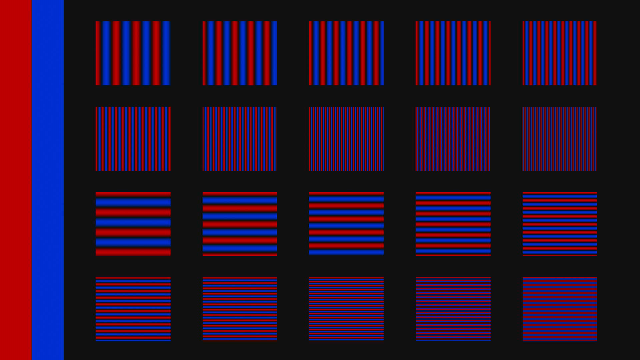

📡 Feed: YOUR-LOST-MACBOOK-PRO.LOCAL (Test Patterns) | Tensor: torch.Size([1, 3, 512, 512])

⏹️ Stream stopped.


In [5]:
from IPython.display import display, clear_output
import PIL.Image

try:
    print("🚀 Visualization Active. Click 'Stop' to end.")
    
    while True:
        t, v, a, m = ndi.recv_capture_v3(ndi_recv, 1000)

        if t == ndi.FRAME_TYPE_VIDEO:
            frame = np.copy(v.data)
            # img_rgb = cv2.cvtColor(frame, cv2.COLOR_YUV2RGB_UYVY)
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGRA2RGB)

            # Preprocessing for CNN
            input_tensor = preprocess(img_rgb)
            input_batch = input_tensor.unsqueeze(0).to(device)

            # --- VISUALIZATION ---
            display_img = cv2.resize(img_rgb, (640, 360))
            img_pil = PIL.Image.fromarray(display_img)
            
            clear_output(wait=True)
            display(img_pil)
            
            # Note: sources[0] is available because we defined it in the previous cell
            print(f"📡 Feed: {sources[0].ndi_name} | Tensor: {input_batch.shape}")

            ndi.recv_free_video_v2(ndi_recv, v)

        elif t == ndi.FRAME_TYPE_ERROR:
            print("❌ NDI Error.")
            break

except KeyboardInterrupt:
    print("\n⏹️ Stream stopped.")

# NOTE: I removed the cleanup from 'finally' here. 
# If you leave it in, you'll have to run Cell 1 EVERY time you want to restart Cell 2.

In [ ]:
# RUN THIS ONLY WHEN YOU ARE FINISHED WITH YOUR SESSION
print("🧹 Cleaning up NDI resources...")
if 'ndi_recv' in locals():
    ndi.recv_connect(ndi_recv, None) 
    ndi.recv_destroy(ndi_recv)
if 'ndi_find' in locals():
    ndi.find_destroy(ndi_find)
ndi.destroy()
print("✅ Resources released.")

Debug Tests

In [ ]:
import ctypes

# Updated to match the strings output you found
libs_to_check = [
    'libavcodec.so.61',
    'libavformat.so.61',
    'libavutil.so.59', # Note: modern FFmpeg util versions vary
    'libswscale.so.8'
]

print("--- Modern Decoder Check ---")
for lib in libs_to_check:
    try:
        ctypes.CDLL(lib)
        print(f"✅ {lib}: LOADED")
    except Exception as e:
        print(f"❌ {lib}: FAILED ({e})")